0
              YEAR          DOY          T2M      T2M_MAX      T2M_MIN  \
count  4108.000000  4108.000000  4108.000000  4108.000000  4108.000000   
mean   2020.131451   180.121227    20.427600    27.838717    14.673169   
min    2015.000000     1.000000    15.260000    18.880000     8.970000   
25%    2017.000000    86.000000    19.460000    26.297500    13.700000   
50%    2020.000000   179.000000    20.360000    27.875000    14.750000   
75%    2023.000000   272.000000    21.400000    29.520000    15.750000   
max    2026.000000   366.000000    25.400000    34.270000    18.750000   
std       3.248907   106.294767     1.440824     2.358770     1.415691   

         T2M_RANGE  PRECTOTCORR         RH2M         WS2M     WS2M_MAX  \
count  4108.000000  4108.000000  4108.000000  4108.000000  4108.000000   
mean     13.165548     1.468162    65.845355     3.061765     4.375241   
min       4.110000     0.000000    28.420000     0.610000     1.160000   
25%      11.467500     0.100000    

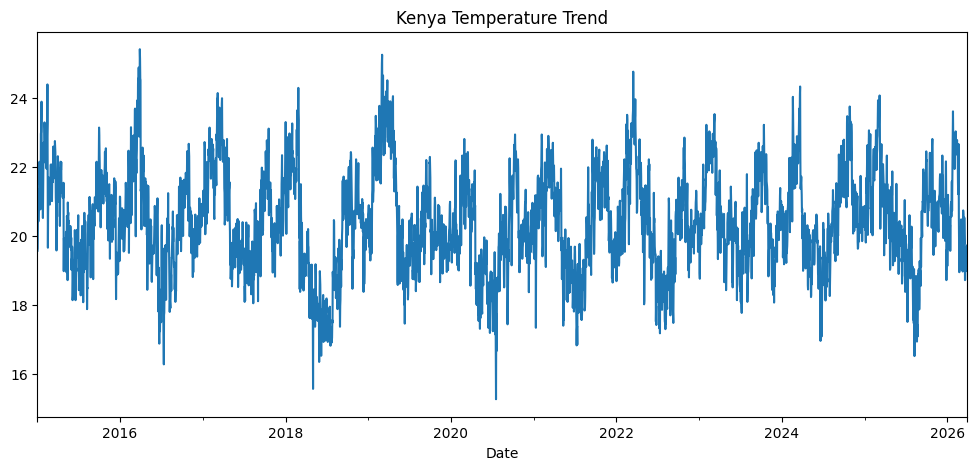

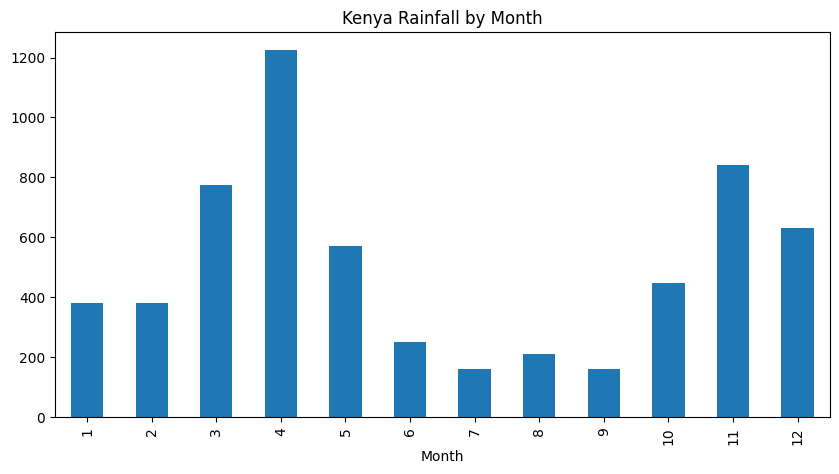

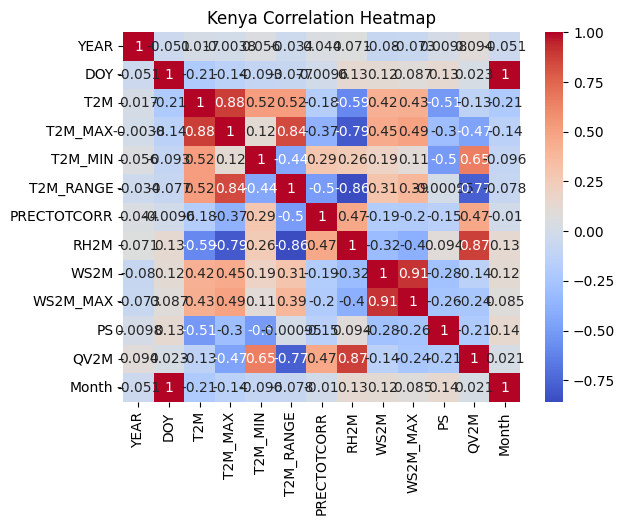

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/kenya.csv')

df["Country"] = "Kenya"

df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df.replace(-999, np.nan, inplace=True)

print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print(df.describe())

print(df.isna().sum())

df.ffill(inplace=True)

monthly_temp = df.groupby("Date")["T2M"].mean()

plt.figure(figsize=(12,5))
monthly_temp.plot()
plt.title("Kenya Temperature Trend")
plt.show()

monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(10,5))
monthly_rain.plot(kind="bar")
plt.title("Kenya Rainfall by Month")
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Kenya Correlation Heatmap")
plt.show()
